# Real-World Missing Data Analysis and Imputation

## Classroom Practice

**Goal:** In real datasets, we usually do not know why values are missing. We inspect the missingness pattern, compare available information, choose an appropriate imputation method, and verify the result.

> MCAR, MAR, and MNAR are assumptions. An incomplete dataset alone usually cannot prove which mechanism is true.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 1. Create Sample Student Data

This is simulated data for practice. A real project would load data from a file or database.

In [2]:
n = 100

df = pd.DataFrame({
    "Student_ID": np.arange(1, n + 1),
    "Age": np.random.randint(18, 25, n),
    "Study_Hours": np.round(np.random.uniform(1, 8, n), 2),
    "Exam_Marks": np.round(np.random.normal(65, 12, n).clip(0, 100), 2),
    "Attendance": np.round(np.random.uniform(50, 100, n), 2),
    "Income": np.round(np.random.normal(35000, 10000, n).clip(15000, 100000), 2)
})

df.head()


,Student_ID,Age,Study_Hours,Exam_Marks,Attendance,Income
0,1,24,1.62,78.71,78.91,43128.62
1,2,21,2.37,74.02,51.80,41296.29
2,3,22,1.32,74.49,73.28,26710.05
3,4,24,3.28,54.09,77.13,29398.19
4,5,20,3.72,81.83,64.33,42472.94


## 2. Create an Unlabeled Missing-Data Dataset

Approximately 10% of cells are randomly replaced with `NaN`.

The analysis will only use the resulting incomplete dataset, not the original missingness rule.

In [3]:
df_missing = df.copy()

random_missing_mask = np.random.random(df_missing.shape) < 0.10
df_missing = df_missing.mask(random_missing_mask)

df_missing.head()


,Student_ID,Age,Study_Hours,Exam_Marks,Attendance,Income
0,1.0,24.0,1.62,78.71,78.91,43128.62
1,NaN,21.0,2.37,74.02,51.80,41296.29
2,3.0,22.0,1.32,74.49,73.28,26710.05
3,4.0,24.0,3.28,54.09,77.13,29398.19
4,5.0,20.0,3.72,81.83,64.33,42472.94


## 3. Check Missing Values

In [4]:
missing_count = df_missing.isna().sum()
missing_percentage = (df_missing.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_summary


,Missing_Count,Missing_Percentage
Student_ID,10,10.0
Age,5,5.0
Study_Hours,10,10.0
Exam_Marks,4,4.0
Attendance,11,11.0
Income,13,13.0


## 4. Visualize the Missingness Pattern

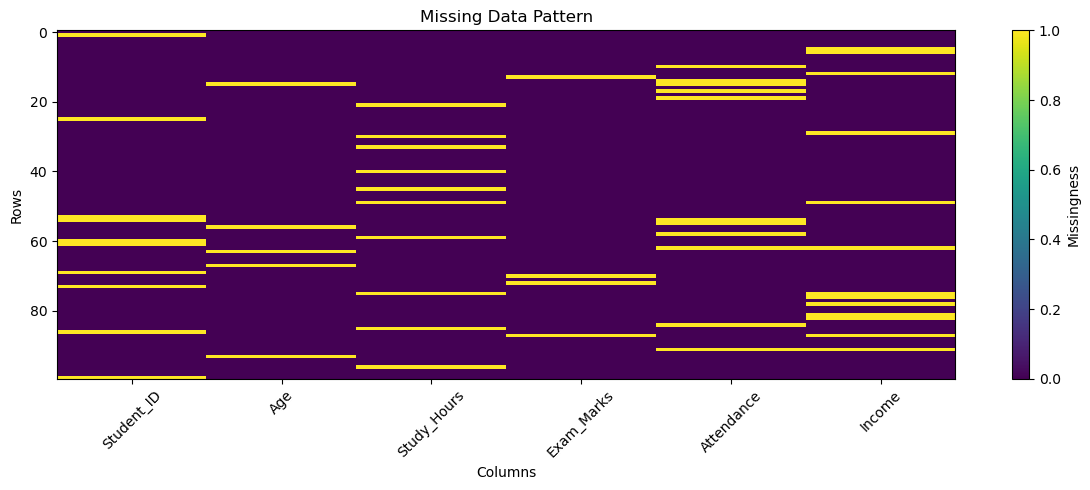

In [5]:
plt.figure(figsize=(12, 5))

plt.imshow(df_missing.isna(), aspect="auto", interpolation="none")
plt.title("Missing Data Pattern")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(range(len(df_missing.columns)), df_missing.columns, rotation=45)
plt.colorbar(label="Missingness")
plt.tight_layout()
plt.show()


## 5. Investigate Missing Exam Marks

We create an indicator:

- `False`: Exam mark is observed
- `True`: Exam mark is missing

We then compare other observed variables. This may reveal a pattern, but it does not prove MCAR or MAR.

In [6]:
analysis_df = df_missing.copy()
analysis_df["Marks_Missing"] = analysis_df["Exam_Marks"].isna()

group_comparison = analysis_df.groupby("Marks_Missing")[
    ["Study_Hours", "Attendance", "Age"]
].mean()

group_comparison.index = ["Marks Observed", "Marks Missing"]
group_comparison


,Study_Hours,Attendance,Age
Marks Observed,4.277791,74.003765,21.285714
Marks Missing,4.700000,54.140000,21.750000


### Compare Missing Rates by Attendance Group

In [7]:
analysis_df["Attendance_Group"] = pd.cut(
    analysis_df["Attendance"],
    bins=[0, 60, 80, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

attendance_missing_rate = (
    analysis_df.groupby("Attendance_Group", observed=False)["Marks_Missing"]
    .mean()
    .mul(100)
    .round(2)
)

attendance_missing_rate


Attendance_Group
Low       13.04
Medium     2.94
High       0.00
Name: Marks_Missing, dtype: float64

## 6. Impute Missing Exam Marks

We use median imputation for this beginner example.

Median is less affected by extreme values than the mean. The correct method depends on the data, missingness assumptions, and project purpose.

In [8]:
df_imputed = df_missing.copy()

median_marks = df_imputed["Exam_Marks"].median()
df_imputed["Exam_Marks"] = df_imputed["Exam_Marks"].fillna(median_marks)

print("Median used:", round(median_marks, 2))


Median used: 68.22


## 7. Verify the Result

In [9]:
print("Missing Exam_Marks before imputation:",
      df_missing["Exam_Marks"].isna().sum())

print("Missing Exam_Marks after imputation:",
      df_imputed["Exam_Marks"].isna().sum())


Missing Exam_Marks before imputation: 4
Missing Exam_Marks after imputation: 0


## 8. Compare Before and After Imputation

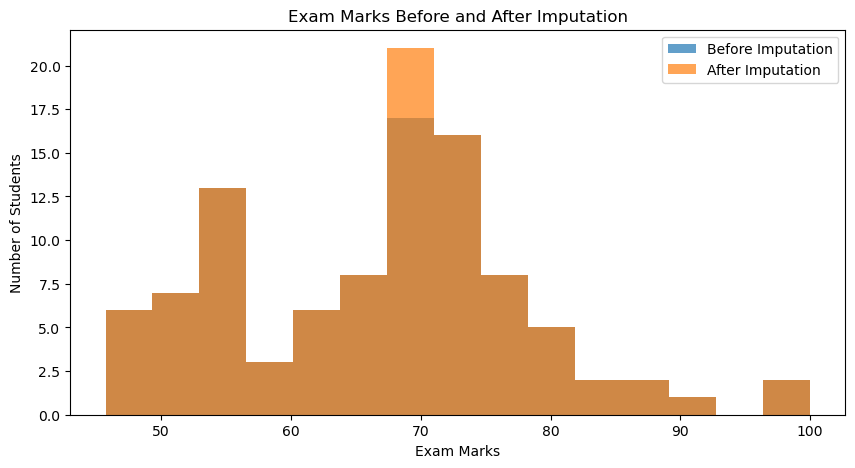

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(df_missing["Exam_Marks"].dropna(), bins=15,
         alpha=0.7, label="Before Imputation")

plt.hist(df_imputed["Exam_Marks"], bins=15,
         alpha=0.7, label="After Imputation")

plt.title("Exam Marks Before and After Imputation")
plt.xlabel("Exam Marks")
plt.ylabel("Number of Students")
plt.legend()
plt.show()


## 9. MCAR, MAR, and MNAR

### MCAR
Missingness is unrelated to observed and unobserved values.

**Example:** A random technical error removes some values.

### MAR
Missingness depends on another observed variable.

**Example:** Missing marks are related to attendance, and attendance is available.

### MNAR
Missingness depends on the missing value itself or unobserved information.

**Example:** Students with very low marks avoid reporting their marks.

### Classroom conclusion

We normally cannot prove the exact missingness mechanism using only an incomplete dataset. We use missingness summaries, visualizations, comparisons, domain knowledge, and information about how the data was collected.

## 10. Short Presentation Script

> First, I check the missing-value count and percentage. Then, I visualize the missingness pattern. After that, I compare records with missing values against records with observed values using other available variables. Based on the data type and distribution, I select an imputation method. In this example, I use the median to fill missing exam marks. Finally, I verify the result and compare the distribution before and after imputation.

**Remember:**

`Check → Analyze → Choose Method → Impute → Verify`

Do not say: “The code proved that the data is MAR.”

Say: “The analysis suggests a possible relationship, but it does not prove the missingness mechanism.”
